<center><h1> Basic Options <h1><center>

# 1. European Call and Put

Let $K$ be the strike price, 
$S_m$ the price of the underlying at expiration (
$m$ years ahead) of the option contract and $y$ the continously compounded interest rate.

The call and put profits (at expiration) are

$$\pi_m^C = \max(0,S_m - K) - e^{my}C$$
$$\pi_m^P = \max(0,K - S_m) - e^{my}P$$

where $C$ and $P$ are the call and put option prices (paid today). In both cases the first term ($\max()$) represents the payoff at expiration, while the second term (
$e^{my}C$ or $e^{my}P$) subtracts the capitalised value of the option price (premium) paid at inception of the contract.

The profit of a straddle is the sum of those of a call and a put.

In [10]:
import numpy as np 
import pandas as pd

S_range = np.array([4.5,5.5])   #possible values of underlying at expiration
K  = 5                 #strike price
C  = 0.4               #call price
P  = 0.4               #put price
(y,m) = (0,1)          #zero interest to keep it simple, 1 year to expiration

CallPayoff = np.maximum(0,S_range-K) 
CallProfit = CallPayoff - np.exp(m*y)*C    

callDataFrame = pd.DataFrame({"S_T" : S_range, "Call Payoff" : CallPayoff, "Call Profit" : CallProfit}, index = ["case 1", "case 2"])

callDataFrame["Exercise?"] = ["yes" if s > K else "no" for s in S_range]

display(callDataFrame)

,S_T,Call Payoff,Call Profit,Exercise?
case 1,4.5,0.0,-0.4,no
case 2,5.5,0.5,0.1,yes


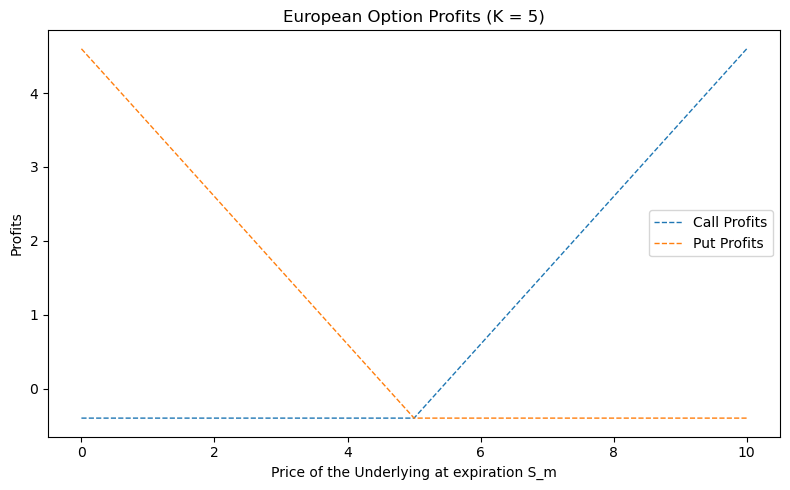

In [20]:
import matplotlib.pyplot as plt

S_range = np.arange(0,10.5,0.5)

CallProfit = np.maximum(0,S_range-K) - np.exp(m*y)*C
PutProfit  = np.maximum(0,K-S_range) - np.exp(m*y)*P


plt.figure(figsize=(8,5))
plt.plot(S_range,CallProfit, label="Call Profits", linewidth = 1, linestyle='--')
plt.plot(S_range,PutProfit, label="Put Profits", linewidth = 1, linestyle='--')
plt.title("European Option Profits (K = 5)")
plt.ylabel("Profits")
plt.xlabel("Price of the Underlying at expiration S_m")
plt.legend()
plt.tight_layout()
plt.show()

### 1.1. A Straddle

A straddle is a portfolio of 1 put and 1 call on the same underlying and based on the same strike $K$. 

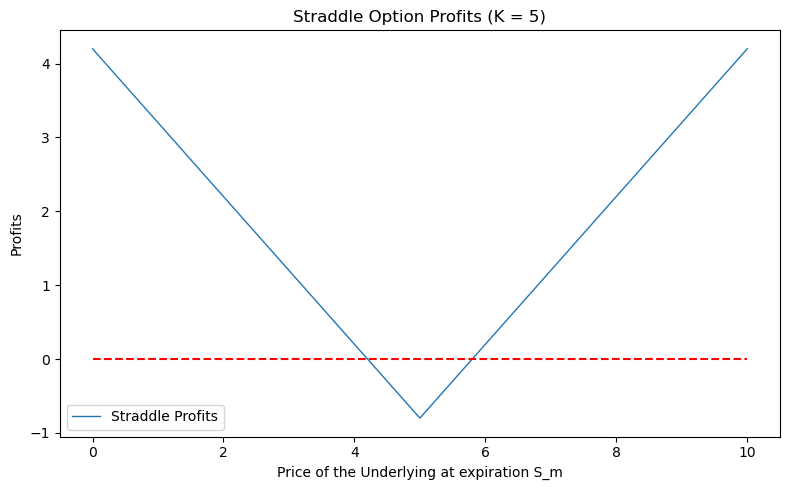

In [26]:
CallProfit = np.maximum(0,S_range-K) - np.exp(m*y)*C
PutProfit  = np.maximum(0,K-S_range) - np.exp(m*y)*P

StraddleProfit = CallProfit + PutProfit

plt.figure(figsize=(8,5))
plt.plot(S_range,StraddleProfit, label="Straddle Profits", linewidth = 1)
plt.hlines(y, xmin = 0, xmax=10, colors='Red',linestyles='--')
plt.title("Straddle Option Profits (K = 5)")
plt.ylabel("Profits")
plt.xlabel("Price of the Underlying at expiration S_m")
plt.legend()
plt.tight_layout()
plt.show()

## 1.2. Put-Call Parity

A no-arbitrage condition says that

\begin{equation}
C_t - P_t = e^{-my} (F_t-K)
\end{equation}

must hold, where $F_m$ is the forward price (on a forward contract with the same time to expiration, $m$, as the option). This is the put-call parity.

When the underlying asset has no dividends (until expiration of the option), then the forward-spot parity says that $F_t=e^{my}S_t$, which can be used in the put-call partity to substitute for 